# Regressão Linear Simples

Usando a relação entre graus Celsius e Fahrenheit ($F = 1.8 \cdot C + 32$).

A rede neural precisa aprender apenas 2 parâmetros: 

**o peso ($w = 1.8$) e o bias ($b = 32$).**

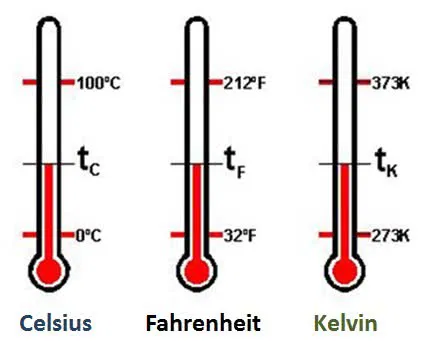

https://www.todamateria.com.br/escalas-termometricas/

https://medium.com/@sadeghiborna/tensorflow-basics-converting-celsius-temperatures-to-fahrenheit-fcf0aa59fbf0

In [2]:
# Bibliotecas
import warnings

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

warnings.filterwarnings('ignore')

### Dados de Treino (Entradas X e Saídas esperadas y)

In [3]:
celsius = np.array([-40, -10,  0,  8, 15, 22,  38], dtype=float)
fahrenheit = np.array([-40,  14, 32, 46, 59, 72, 100], dtype=float)

<br>

### Definição da Arquitetura do Modelo



In [4]:
# 1 camada densa, 1 único neurônio, 1 valor de entrada (como um Perceptron)
modelo = Sequential([
    Dense(units=1, input_shape=[1])
])

W0000 00:00:1787957238.324118  233511 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


##### <font color='red'>Dense(units=1, input_shape=[1]) cria a famosa equação da reta $y = w \cdot x + b$.</font>

<br>

### Compilação do Modelo

In [5]:
# Definimos como a rede calcula o erro (loss) e como atualiza os pesos (optimizer)
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_squared_error' # lembram-- erro quadrático médio
)

##### <font color='red'>O loss (loss function) é a métrica que queremos minimizar e o optimizer é o algoritmo que ajusta os ($w$ e $b$).</font>

<br>

### Treinamento

In [6]:
print("Treinando a rede neural...")
historico = modelo.fit(celsius, fahrenheit, epochs=500, verbose=0)
print("Treinamento concluído!")

Treinando a rede neural...
Treinamento concluído!


##### <font color='red'>O fit segue a mesma ideia que já conhecemos.</font>

<br>

### Fazendo uma Previsão

In [7]:
valor_celsius = 100.0  # 100°C deve resultar em 212°F
previsao = modelo.predict(np.array([valor_celsius]))
print(f"\nPrevisão para {valor_celsius}°C: {previsao[0][0]:.2f}°F (Esperado: 212°F)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Previsão para 100.0°C: 211.32°F (Esperado: 212°F)


##### <font color='red'>O predict segue a mesma ideia que já conhecemos.</font>

<br>

### Inspecionando o que a Rede Aprendeu (Pesos e Bias)

In [8]:
pesos, bias = modelo.layers[0].get_weights()
print(f"\nPeso aprendido (w): {pesos[0][0]:.4f} (Fórmula real: 1.8)")
print(f"Bias aprendido (b): {bias[0]:.4f} (Fórmula real: 32.0)")


Peso aprendido (w): 1.8227 (Fórmula real: 1.8)
Bias aprendido (b): 29.0546 (Fórmula real: 32.0)
